# Portugal – Erneuerbare Potenziale (`01_potenzialanalyse.ipynb`)

Dieses Notebook deckt den ersten Teil von **Assignment 4** ab: die Flächeneignungsanalyse
und die Kapazitätsfaktor-Zeitreihen für ein 100%-erneuerbares Stromsystem in Portugal.

**Aufbau:**
1. Regionen (5 NUTS-2) und Exclusive Economic Zone (EEZ)
2. Flächeneignung: Solar, Onshore-Wind, Offshore-Wind
3. ERA5-Wetterdaten (`atlite`-Cutout, Jahr 2013)
4. Kapazitätsfaktor-Zeitreihen je Region und Technologie

**Datengrundlage:** vom Kurs bereitgestellte Daten (`assignment-4-data.zip`, TU Berlin
tubcloud), GADM (Verwaltungsgrenzen), Copernicus LC100 (Landbedeckung), WDPA
(Schutzgebiete), GEBCO (Höhen/Tiefen), Marine Regions (EEZ), ERA5 (Wetterdaten via CDS).

**Output dieses Notebooks** (Input für `02_modell.ipynb`):
`regions`, `offshore_regions`, `capacity_factors_solar`, `capacity_factors_onshore`,
`capacity_factors_offshore`.

In [11]:

import geopandas as gpd
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from urllib.request import urlretrieve
import os
import zipfile

import logging
logging.getLogger("rasterio").setLevel(logging.ERROR)

## 1. Regionen und EEZ

**Vorgabe (Aufgabenstellung):** mindestens 5 Regionen aus GADM bilden, je Region einen
repräsentativen Punkt bestimmen (spätere Bus-Koordinate im PyPSA-Modell) und – da
Portugal nicht Binnenland ist – zusätzlich die Exclusive Economic Zone (EEZ) extrahieren.

Wir nutzen die GADM-Distrikte (Ebene ADM_1) und aggregieren sie zu den 5 amtlichen
NUTS-2-Regionen: Norte, Centro, Lisboa, Alentejo, Algarve.

In [12]:
# GADM-Verwaltungsgrenzen (Distrikt-Ebene) aus dem Aufgaben-Ordner laden
fn = "gadm_410-levels-ADM_1-PRT.gpkg"
url = "https://tubcloud.tu-berlin.de/s/567ckizz2Y6RLQq/download?path=/gadm&files=" + fn
if not os.path.exists(fn):
    print("Lade GADM (Portugal) …")
    urlretrieve(url, fn)

gadm = gpd.read_file(fn)
print("Distrikte gesamt:", len(gadm))
print("Spalten:", list(gadm.columns))
print(sorted(gadm["NAME_1"].tolist()))

Distrikte gesamt: 20
Spalten: ['GID_0', 'GID_1', 'COUNTRY', 'NAME_1', 'geometry']
['Aveiro', 'Azores', 'Beja', 'Braga', 'Bragança', 'Castelo Branco', 'Coimbra', 'Faro', 'Guarda', 'Leiria', 'Lisboa', 'Madeira', 'Portalegre', 'Porto', 'Santarém', 'Setúbal', 'Viana do Castelo', 'Vila Real', 'Viseu', 'Évora']


In [13]:
# Übersee (Azoren/Madeira) laut Aufgabe weglassen ("You may disregard overseas territories")
mainland = gadm[~gadm["NAME_1"].isin(["Azores", "Madeira", "Açores"])].copy()

# GADM-Distrikte zu den 5 amtlichen NUTS-2-Regionen zusammenfassen.
# Vereinfachung: der Distrikt Setúbal wird komplett Lisboa zugeordnet. Amtlich gehört
# die südliche Küste des Distrikts (Alentejo Litoral, z.B. Sines) zu Alentejo – das
# verschiebt etwas Offshore-Potenzial von Alentejo zu Lisboa (siehe Offshore-Abschnitt).
nuts2 = {
    "Viana do Castelo": "Norte", "Braga": "Norte", "Porto": "Norte",
    "Vila Real": "Norte", "Bragança": "Norte",
    "Aveiro": "Centro", "Viseu": "Centro", "Guarda": "Centro",
    "Coimbra": "Centro", "Castelo Branco": "Centro", "Leiria": "Centro",
    "Santarém": "Centro",
    "Lisboa": "Lisboa", "Setúbal": "Lisboa",
    "Portalegre": "Alentejo", "Évora": "Alentejo", "Beja": "Alentejo",
    "Faro": "Algarve",
}
mainland["region"] = mainland["NAME_1"].map(nuts2)
assert mainland["region"].notna().all(), "Nicht alle Distrikte wurden einer Region zugeordnet!"

# Distrikte je Region zu einer Fläche zusammenfassen + repräsentativen Punkt bestimmen
regions = mainland.dissolve(by="region").reset_index()[["region", "geometry"]]
rep = regions.geometry.representative_point()
regions["x"], regions["y"] = rep.x, rep.y
print(regions[["region", "x", "y"]])

     region         x          y
0  Alentejo -7.823876  38.491093
1   Algarve -8.149914  37.255175
2    Centro -7.903626  39.973028
3    Lisboa -8.461003  38.297461
4     Norte -7.496424  41.577520


In [14]:
# Exclusive Economic Zone (EEZ) für Portugal, ohne Azoren/Madeira
world_eez = gpd.read_file("eez_v11.gpkg")
pt = world_eez[world_eez["TERRITORY1"] == "Portugal"].copy()
inseln = pt["GEONAME"].str.contains("Madeira|Azores|Açores", case=False, na=False)
eez = pt[~inseln].copy()
print("EEZ-Teile fürs Festland:", len(eez))

EEZ-Teile fürs Festland: 1


Gespeichert: portugal_regions.gpkg, portugal_eez.gpkg


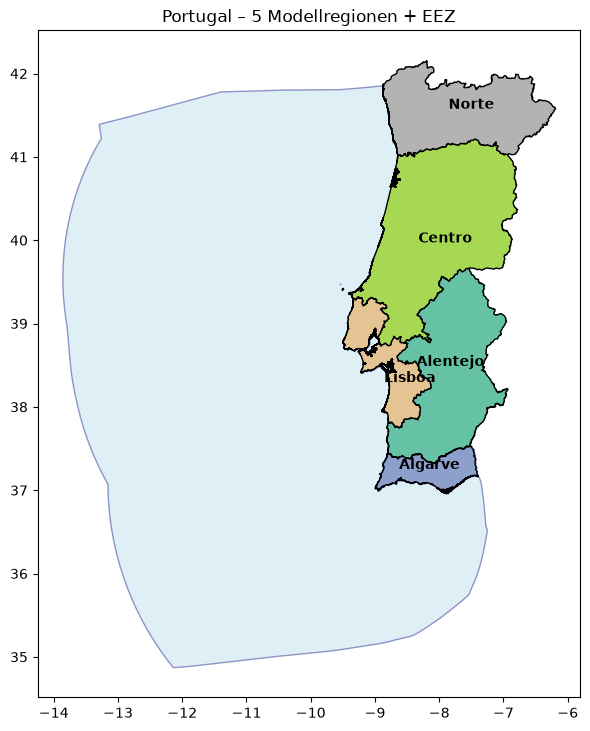

In [15]:
# Kontroll-Karte: 5 Regionen + EEZ, und beides für spätere Notebooks zwischenspeichern
ax = eez.plot(facecolor="lightblue", edgecolor="navy", alpha=0.4, figsize=(7, 9))
regions.plot(ax=ax, column="region", cmap="Set2", edgecolor="black")
for _, r in regions.iterrows():
    ax.annotate(r["region"], (r["x"], r["y"]), ha="center", weight="bold")
ax.set_title("Portugal – 5 Modellregionen + EEZ")

regions.to_file("portugal_regions.gpkg", driver="GPKG")
eez.to_file("portugal_eez.gpkg", driver="GPKG")
print("Gespeichert: portugal_regions.gpkg, portugal_eez.gpkg")

## 2. Flächeneignung

Wir bestimmen, welche Flächen für Solar, Onshore-Wind und Offshore-Wind nutzbar sind.
Die Kriterien unterscheiden sich je Technologie (siehe Kriterien-Tabelle der
Aufgabenstellung). Datengrundlage: Landbedeckung (Copernicus LC100, 100 m) und
Schutzgebiete (WDPA).

In [16]:
import rasterio as rio
from atlite.gis import ExclusionContainer, shape_availability
from rasterio.plot import show

# Landbedeckung Portugal (Copernicus LC100) aus dem Aufgaben-Ordner
fn_lc = "PROBAV_LC100_global_v3.0.1_2019-nrt_Discrete-Classification-map_EPSG-4326-PT.tif"
url_lc = ("https://tubcloud.tu-berlin.de/s/567ckizz2Y6RLQq/download"
          "?path=/copernicus-glc&files=" + fn_lc)
if not os.path.exists(fn_lc):
    print("Lade Landbedeckung …")
    urlretrieve(url_lc, fn_lc)

with rio.open(fn_lc) as src:
    lc = src.read(1)
    print("CRS:", src.crs)
    print("nodata-Wert:", src.nodata)
print("vorhandene Klassen-Codes:", np.unique(lc))

CRS: EPSG:4326
nodata-Wert: 255.0
vorhandene Klassen-Codes: [ 20  30  40  50  60  80  90 111 114 115 116 121 124 125 126 200 255]


### WDPA-Schutzgebiete als Ausschluss

Die Schutzgebiete liegen als Raster vor. Wir prüfen zunächst die Kodierung (welcher Wert
steht für "geschützt"), um sie korrekt als Ausschlussfläche einzubinden.

In [17]:
# WDPA-Schutzgebiete (Raster) aus dem Aufgaben-Ordner
fn_wdpa = "WDPA_Oct2022_Public_shp-PRT.tif"
url_wdpa = ("https://tubcloud.tu-berlin.de/s/567ckizz2Y6RLQq/download"
            "?path=/wdpa&files=" + fn_wdpa)
if not os.path.exists(fn_wdpa):
    print("Lade WDPA-Schutzgebiete …")
    urlretrieve(url_wdpa, fn_wdpa)

with rio.open(fn_wdpa) as src:
    wdpa = src.read(1)
    print("CRS:", src.crs)
    print("nodata-Wert:", src.nodata)
print("vorhandene Werte:", np.unique(wdpa))

CRS: ESRI:54009
nodata-Wert: None
vorhandene Werte: [0 1]


### 2.1 Solar

**Kriterien (Aufgabenstellung):** nur geeignete Landbedeckungsklassen, keine
Naturschutzgebiete.

Solar: 32.1 % der Landesfläche nutzbar


Text(0.5, 1.0, 'Solar-Eignung Portugal (32.1 % nutzbar)')

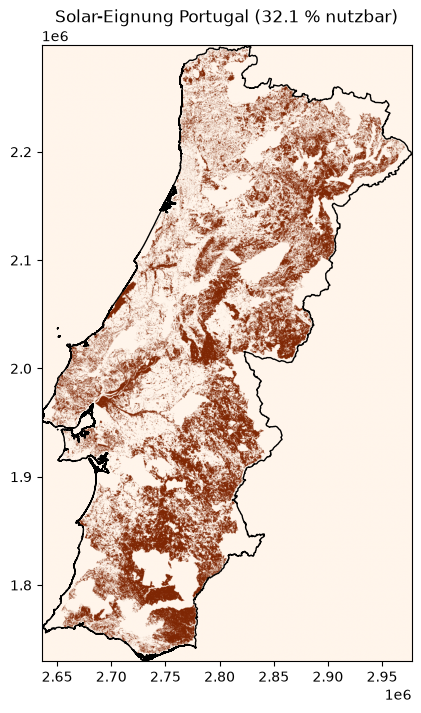

In [18]:
# Portugal-Festland als eine metrische Fläche (EPSG:3035, gültig für Europa)
CRS = 3035
pt_land = regions.to_crs(CRS).dissolve().geometry
flaeche_gesamt = pt_land.area.iloc[0]

# Excluder für Solar
excluder_solar = ExclusionContainer(crs=CRS, res=100)

# a) nur geeignete Landbedeckungsklassen behalten (invert=True = nur diese einschließen)
#    20/30/40/60 = Sträucher, krautige Vegetation, Ackerland, kahle Flächen
geeignet_solar = [20, 30, 40, 60]
excluder_solar.add_raster(fn_lc, codes=geeignet_solar, crs=4326,
                          invert=True, nodata=255)

# b) Schutzgebiete ausschließen (Wert 1 = geschützt); WDPA ist in ESRI:54009
excluder_solar.add_raster(fn_wdpa, codes=[1], crs="ESRI:54009")

# Eignung berechnen
band, transform = shape_availability(pt_land, excluder_solar)
anteil_solar = band.sum() * excluder_solar.res**2 / flaeche_gesamt * 100
print(f"Solar: {anteil_solar:.1f} % der Landesfläche nutzbar")

# Karte
fig, ax = plt.subplots(figsize=(5, 8))
pt_land.plot(ax=ax, color="none", edgecolor="black")
show(band, transform=transform, cmap="Oranges", ax=ax)
ax.set_title(f"Solar-Eignung Portugal ({anteil_solar:.1f} % nutzbar)")

### 2.2 Onshore-Wind

**Kriterien (Aufgabenstellung):** geeignete Landbedeckung, keine Schutzgebiete,
max. Höhe 2000 m, 10 km Abstand zu Flughäfen, 300 m Abstand zu großen Straßen,
1000 m Abstand zu bebauten Gebieten.

Flughäfen und Straßen (Natural Earth) liegen im Aufgaben-ZIP im Hauptordner.

In [19]:
# Flughäfen und Straßen liegen im entpackten Aufgaben-Ordner
ordner_pfad = "assignment-4-data"

for ziel in ["ne_10m_airports.gpkg", "ne_10m_roads.gpkg"]:
    if not os.path.exists(ziel):
        import shutil
        quelle = os.path.join(ordner_pfad, ziel)
        assert os.path.exists(quelle), f"{quelle} nicht gefunden."
        shutil.copy(quelle, ziel)
        print("kopiert:", ziel)

airports = gpd.read_file("ne_10m_airports.gpkg")
roads = gpd.read_file("ne_10m_roads.gpkg")
print("Flughäfen weltweit:", len(airports), "| Straßen weltweit:", len(roads))
print("Flughäfen-CRS:", airports.crs, "| Straßen-CRS:", roads.crs)

Flughäfen weltweit: 893 | Straßen weltweit: 56600
Flughäfen-CRS: EPSG:4326 | Straßen-CRS: EPSG:4326


In [20]:
# Auf Portugal + unmittelbare Umgebung zuschneiden (schneller als weltweit zu arbeiten)
pt_umriss = regions.dissolve().to_crs(4326).geometry.iloc[0]
airports_pt = airports[airports.intersects(pt_umriss)].copy()
roads_pt = roads[roads.intersects(pt_umriss)].copy()

print("Flughäfen in Portugal:", len(airports_pt))
print("Straßen in Portugal:", len(roads_pt))

Flughäfen in Portugal: 3
Straßen in Portugal: 80


### Onshore-Wind: Excluder Schritt für Schritt

Wir starten mit geeigneter Landbedeckung und ergänzen nacheinander: Schutzgebiete,
Höhe > 2000 m, 10 km um Flughäfen, 300 m um große Straßen, 1000 m um bebaute Gebiete.
Nach jedem Kriterium zeigen wir die verbleibende Fläche – so lässt sich in der
Präsentation der Effekt jedes einzelnen Kriteriums nachvollziehen.

In [21]:
# Große Straßen auswählen (Fähren & kleine Wege raus)
grosse_typen = ["Major Highway", "Secondary Highway", "Beltway", "Bypass"]
roads_gross = roads_pt[roads_pt["type"].isin(grosse_typen)].copy()
print("große Straßen in PT:", len(roads_gross), "von", len(roads_pt))

# Als Dateien ablegen, damit der Excluder sie per Pfad einbinden kann
airports_pt.to_file("airports_pt.gpkg", driver="GPKG")
roads_gross.to_file("roads_pt.gpkg", driver="GPKG")

# Wind-Excluder anlegen
excluder_wind = ExclusionContainer(crs=CRS, res=100)

def zeige_wind(titel):
    """Berechnet den verbleibenden nutzbaren Flächenanteil für excluder_wind,
    gibt ihn aus, zeichnet eine Karte und liefert den Prozentwert zurück."""
    band, transform = shape_availability(pt_land, excluder_wind)
    anteil = band.sum() * excluder_wind.res**2 / flaeche_gesamt * 100
    print(f"{titel}: {anteil:.1f} % nutzbar")
    fig, ax = plt.subplots(figsize=(5, 8))
    pt_land.plot(ax=ax, color="none", edgecolor="black")
    show(band, transform=transform, cmap="Blues", ax=ax)
    ax.set_title(f"{titel}\n({anteil:.1f} % nutzbar)")
    return anteil

große Straßen in PT: 67 von 80


Wind K1: Landbedeckung: 43.3 % nutzbar


np.float64(43.26661132651522)

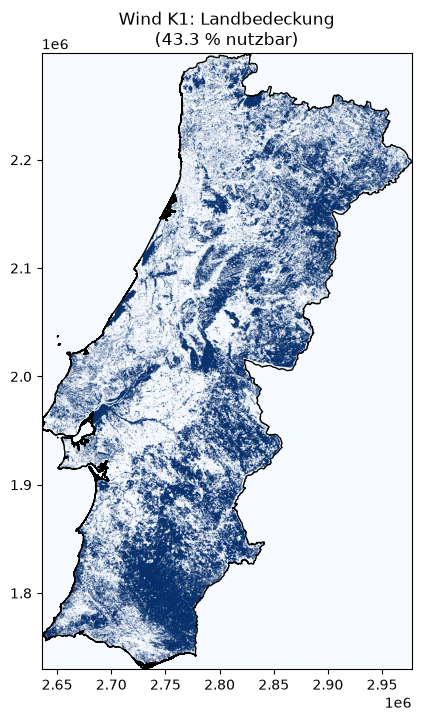

In [22]:
# K1: geeignete Landbedeckung (wie Solar: offene, nicht bebaute Flächen)
geeignet_wind = [20, 30, 40, 60]
excluder_wind.add_raster(fn_lc, codes=geeignet_wind, crs=4326, invert=True, nodata=255)
zeige_wind("Wind K1: Landbedeckung")

Wind K2: + Schutzgebiete: 32.1 % nutzbar


np.float64(32.13566544859678)

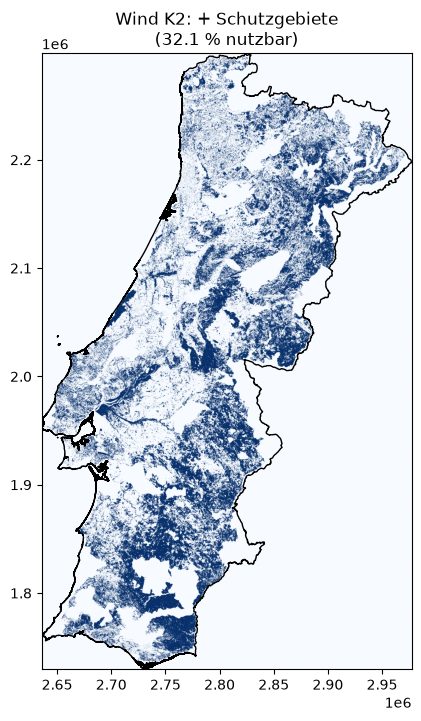

In [23]:
# K2: Schutzgebiete ausschließen (WDPA, ESRI:54009)
excluder_wind.add_raster(fn_wdpa, codes=[1], crs="ESRI:54009")
zeige_wind("Wind K2: + Schutzgebiete")

### Zwischenschritt: Höhendaten (GEBCO)

Für Kriterium 3 (Höhe ≤ 2000 m) brauchen wir Höhendaten aus GEBCO. **Der GEBCO-Ausschnitt
im Aufgaben-ZIP hat fehlerhafte Koordinaten** (er zeigt auf die Pyrenäen statt auf
Portugal) – wir verwenden daher stattdessen die Originaldatei aus dem atlite-Workshop
und wandeln sie selbst in ein georeferenziertes GeoTIFF um. Auf Mac ist dafür der
NetCDF-GDAL-Treiber nötig (`conda install -c conda-forge libgdal-netcdf`, danach Kernel
neu starten) – der HDF5-Treiber allein liest zwar Werte, verwirft aber die
Georeferenzierung.

In [24]:
# Korrekte GEBCO-Höhendaten (Original aus dem atlite-Workshop) herunterladen
urlretrieve(
    "https://tubcloud.tu-berlin.de/s/XoDpBcweJHmYKgF/download/GEBCO_2014_2D-PT.nc",
    "GEBCO_2014_2D-PT.nc",
)

('GEBCO_2014_2D-PT.nc', <http.client.HTTPMessage at 0x169bd0610>)

In [25]:
import xarray as xr
import rioxarray   # registriert den .rio-Accessor auf xarray-Objekten

# In ein georeferenziertes GeoTIFF wandeln
ds2 = xr.open_dataset("GEBCO_2014_2D-PT.nc")
var = "elevation" if "elevation" in ds2.data_vars else list(ds2.data_vars)[0]
elev = ds2[var].rio.set_spatial_dims(x_dim="lon", y_dim="lat").rio.write_crs("EPSG:4326")
elev.rio.to_raster("gebco_pt.tif")

with rio.open("gebco_pt.tif") as src:
    print("Bounds von gebco_pt.tif:", [round(b, 1) for b in src.bounds])
    # sollte grob Portugal entsprechen: lon -10..-6, lat 37..42

Bounds von gebco_pt.tif: [-9.5, 42.1, -6.2, 37.0]


/Users/luisboettcher/miniforge3/envs/energy/lib/python3.11/site-packages/IPython/core/interactiveshell.py:3225: SerializationWarning: saving variable None with floating point data as an integer dtype without any _FillValue to use for NaNs
  result = runner(coro)


Wind K1-K3: Landbedeckung + Schutz + Höhe: 32.1 % nutzbar


np.float64(32.13566544859678)

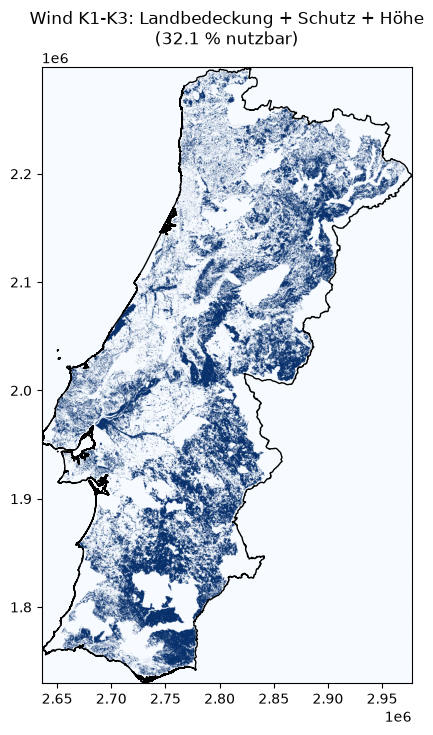

In [26]:
# K3: max. Höhe 2000 m (mit der korrekt georeferenzierten GEBCO-Datei)
excluder_wind.add_raster("gebco_pt.tif", codes=lambda x: x > 2000, crs=4326)
zeige_wind("Wind K1-K3: Landbedeckung + Schutz + Höhe")

Wind K4: + 10 km um Flughäfen: 32.0 % nutzbar
Wind K5: + 300 m um große Straßen: 31.1 % nutzbar
Wind K6: + 1000 m um Siedlungen (alle 6 Kriterien): 18.1 % nutzbar


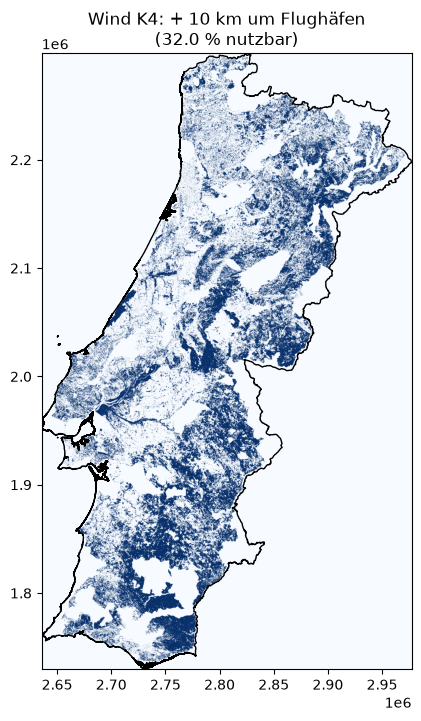

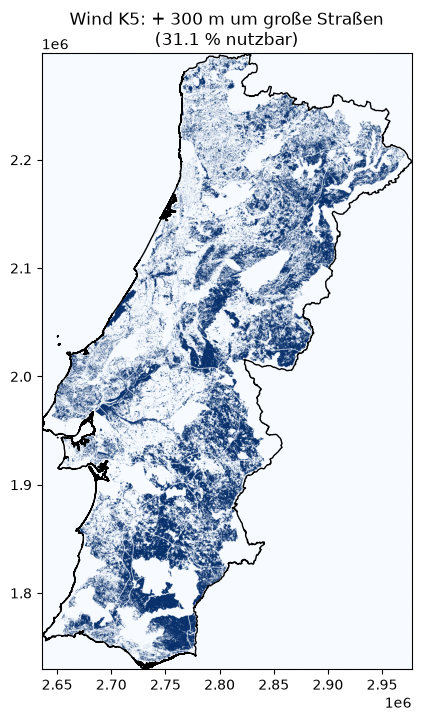

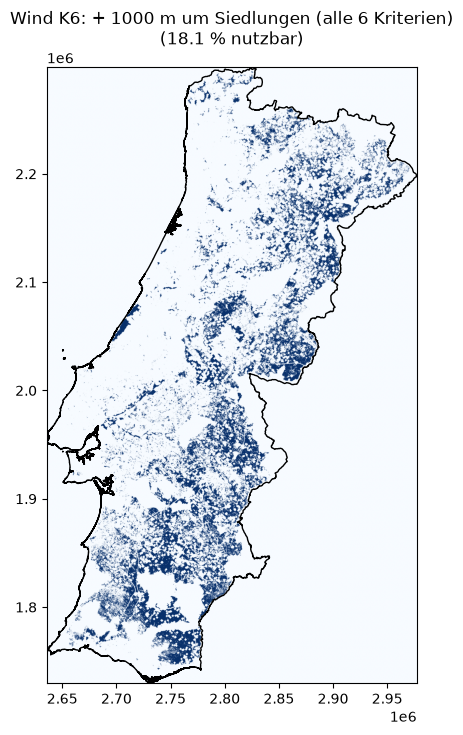

In [27]:
# K4: 10 km Puffer um Flughäfen
excluder_wind.add_geometry("airports_pt.gpkg", buffer=10000)
zeige_wind("Wind K4: + 10 km um Flughäfen")

# K5: 300 m Puffer um große Straßen
excluder_wind.add_geometry("roads_pt.gpkg", buffer=300)
zeige_wind("Wind K5: + 300 m um große Straßen")

# K6: 1000 m Puffer um bebaute Gebiete (Landbedeckungs-Klasse 50 = städtisch)
excluder_wind.add_raster(fn_lc, codes=[50], crs=4326, buffer=1000, nodata=255)
anteil_wind = zeige_wind("Wind K6: + 1000 m um Siedlungen (alle 6 Kriterien)")

In [28]:
print(f"Solar-Eignung:   {anteil_solar:.1f} %  der Landesfläche")
print(f"Onshore-Wind:    {anteil_wind:.1f} %  der Landesfläche (nach allen 6 Kriterien)")
# excluder_solar und excluder_wind bleiben im Speicher für die Kapazitätsfaktor-Berechnung
# in Abschnitt 4 (dort wird die Eignung mit dem ERA5-Raster verschnitten).

Solar-Eignung:   32.1 %  der Landesfläche
Onshore-Wind:    18.1 %  der Landesfläche (nach allen 6 Kriterien)


### 2.3 Offshore-Wind

**Kriterien (Aufgabenstellung):** nur innerhalb der EEZ, Wassertiefe bis 50 m, keine
Schutzgebiete, mindestens 10 km Abstand zur Küste.

Die Analysefläche wechselt vom Land aufs Meer. Kriterien 1 ("nur EEZ") und 4
("10 km Küstenabstand") lösen wir über die **Analysefläche** (EEZ minus 10-km-Puffer),
Kriterien 2 ("Tiefe") und 3 ("Schutzgebiete") über den **ExclusionContainer** – analog
zu Solar/Onshore.

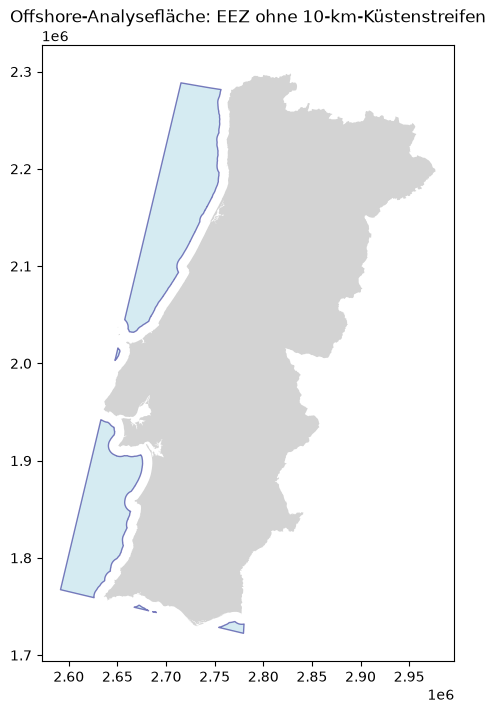

In [29]:
from shapely.geometry import box

# Festland als eine Geometrie in CRS 3035 (pt_land aus dem Solar-Schritt)
land_geom = pt_land.iloc[0]

# Gesamte EEZ in CRS 3035
eez_geom = eez.to_crs(CRS).dissolve().geometry.iloc[0]

# Analysefläche: EEZ minus 10-km-Küstenpuffer
offshore_area = eez_geom.difference(land_geom.buffer(10_000))

# Auf die GEBCO-Abdeckung beschränken (nur dort kennen wir die Wassertiefe;
# außerhalb ist offener Atlantik, also ohnehin > jede sinnvolle Tiefen-Schwelle)
with rio.open("gebco_pt.tif") as src:
    gebco_box = gpd.GeoSeries([box(*src.bounds)], crs=4326).to_crs(CRS).iloc[0]
offshore_area = offshore_area.intersection(gebco_box)

offshore_shape = gpd.GeoSeries([offshore_area], index=["PT-offshore"], crs=CRS)

# Kontroll-Plot
ax = gpd.GeoSeries([land_geom], crs=CRS).plot(color="lightgrey", figsize=(6, 8))
offshore_shape.plot(ax=ax, color="lightblue", edgecolor="navy", alpha=0.5)
ax.set_title("Offshore-Analysefläche: EEZ ohne 10-km-Küstenstreifen");

### Bodenfest vs. schwimmend: Begründung der Abweichung von 50 m

Die Aufgabenstellung nennt 50 m Wassertiefe als Richtwert für bodenfeste Fundamente,
erlaubt aber ausdrücklich, mit angemessener Begründung davon abzuweichen ("you can
deviate from the suggested numbers below with reasonable justification"). Wir prüfen
daher beide Varianten, bevor wir uns festlegen.

In [30]:
# Vergleich: bodenfest (<=50 m, Fundament auf dem Meeresboden) vs. schwimmend (<=1000 m)
for tiefe, label in [(-50, "bodenfest (<=50 m)"), (-1000, "schwimmend (<=1000 m)")]:
    test_excluder = ExclusionContainer(crs=CRS, res=100)
    test_excluder.add_raster("gebco_pt.tif", codes=lambda x, t=tiefe: x < t, crs=4326)
    test_excluder.add_raster(fn_wdpa, codes=[1], crs="ESRI:54009")
    test_band, _ = shape_availability(offshore_shape, test_excluder)
    test_km2 = test_band.sum() * test_excluder.res**2 / 1e6
    print(f"{label:22s}: {test_km2:8.1f} km²  ->  {test_km2 * 3 / 1000:6.2f} GW  (bei 3 MW/km²)")

bodenfest (<=50 m)    :    139.6 km²  ->    0.42 GW  (bei 3 MW/km²)
schwimmend (<=1000 m) :  11024.3 km²  ->   33.07 GW  (bei 3 MW/km²)


**Ergebnis:** Bodenfest liefert nur rund 0,4 GW – Portugals Kontinentalschelf fällt
steil ab, sodass kaum Fläche innerhalb von 50 m Tiefe *und* außerhalb der 10-km-Zone
übrig bleibt. Als eigene Technologie im Modell wäre das vernachlässigbar. Schwimmende
Anlagen sind für Portugal real erprobt (WindFloat Atlantic, netzgekoppelt seit 2020,
vor Viana do Castelo) und liefern ein für das Modell relevantes Potenzial.

**Wir verwenden daher schwimmend (≤ 1000 m) für die weitere Analyse** – siehe folgende
Zelle.

Offshore-Wind: 3.5 % der EEZ nutzbar (<=1000 m Tiefe/schwimmend, >10 km Küste, ohne Schutzgebiete)


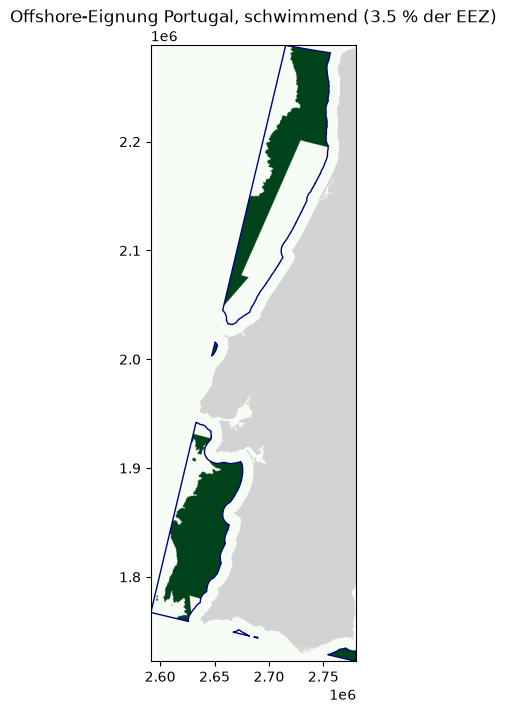

In [31]:
excluder_offshore = ExclusionContainer(crs=CRS, res=100)

# Wassertiefe: schwimmende Fundamente bis 1000 m (siehe Begründung oben)
excluder_offshore.add_raster("gebco_pt.tif", codes=lambda x: x < -1000, crs=4326)

# Schutzgebiete: exakt wie onshore (WDPA-Raster, ESRI:54009)
excluder_offshore.add_raster(fn_wdpa, codes=[1], crs="ESRI:54009")

band, transform = shape_availability(offshore_shape, excluder_offshore)

anteil_offshore = band.sum() * excluder_offshore.res**2 / eez_geom.area * 100
print(f"Offshore-Wind: {anteil_offshore:.1f} % der EEZ nutzbar "
      f"(<=1000 m Tiefe/schwimmend, >10 km Küste, ohne Schutzgebiete)")

fig, ax = plt.subplots(figsize=(6, 8))
gpd.GeoSeries([land_geom], crs=CRS).plot(ax=ax, color="lightgrey")
offshore_shape.plot(ax=ax, color="none", edgecolor="navy")
show(band, transform=transform, cmap="Greens", ax=ax)
ax.set_title(f"Offshore-Eignung Portugal, schwimmend ({anteil_offshore:.1f} % der EEZ)");

In [32]:
eligible_km2 = band.sum() * excluder_offshore.res**2 / 1e6
print(f"Geeignete Fläche:  {eligible_km2:.1f} km²")
print(f"Installierbar:     {eligible_km2 * 3 / 1000:.2f} GW  (bei 3 MW/km²)")
# Hinweis: die geeignete Fläche reicht stellenweise bis an den Rand der verfügbaren
# GEBCO-Kachel (v.a. im Norden und Süden) – das reale Potenzial ist damit eher
# konservativ (unterschätzt), was für eine Potenzialanalyse die sichere Seite ist.

Geeignete Fläche:  11024.3 km²
Installierbar:     33.07 GW  (bei 3 MW/km²)


### Offshore-Fläche auf Küstenregionen aufteilen

Für das PyPSA-Modell braucht jede Küstenregion ihre eigene Offshore-Fläche. Wir kacheln
das Meer in 2-km-Zellen und ordnen jede Zelle der nächstgelegenen Region zu
(`sjoin_nearest`). Das ist robuster als eine reine Punkt-Voronoi-Zerlegung, weil es auch
für Regionen funktioniert, deren Repräsentativpunkt weit im Landesinneren liegt (z.B.
Alentejo).

Küstenregionen mit Offshore-Anteil: ['Alentejo', 'Algarve', 'Centro', 'Lisboa', 'Norte']


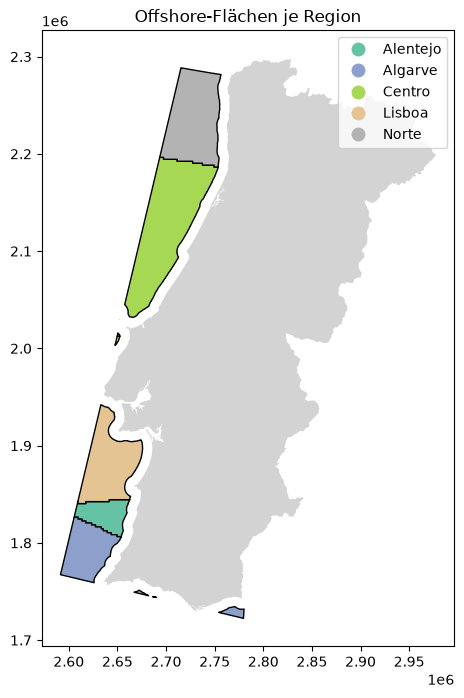

In [33]:
from shapely.geometry import box as shp_box

regions_m = regions.to_crs(CRS).reset_index(drop=True)

# Meer in 2-km-Zellen kacheln
minx, miny, maxx, maxy = offshore_area.bounds
step = 2000
cells_grid = [shp_box(x, y, x + step, y + step)
              for x in np.arange(minx, maxx, step)
              for y in np.arange(miny, maxy, step)]
grid = gpd.GeoDataFrame(geometry=cells_grid, crs=CRS)
grid["geometry"] = grid.geometry.intersection(offshore_area)   # auf Meer zuschneiden
grid = grid[~grid.geometry.is_empty].reset_index(drop=True)

# jede Zelle der nächsten Region zuordnen (über den Zellmittelpunkt)
cent = grid.copy()
cent["geometry"] = grid.geometry.centroid
cent = gpd.sjoin_nearest(cent, regions_m[["region", "geometry"]], how="left")
grid["region"] = cent["region"].values

offshore_regions = grid.dissolve(by="region")[["geometry"]]
print("Küstenregionen mit Offshore-Anteil:", offshore_regions.index.tolist())

# Karte
ax = gpd.GeoSeries([land_geom], crs=CRS).plot(color="lightgrey", figsize=(6, 8))
offshore_regions.reset_index().plot(ax=ax, column="region", cmap="Set2",
                                    edgecolor="k", legend=True)
ax.set_title("Offshore-Flächen je Region");

In [34]:
# Geeignete Fläche und installierbare Leistung je Küstenregion
zeilen = []
for reg, geom in offshore_regions.geometry.items():
    shp = gpd.GeoSeries([geom], index=[reg], crs=CRS)
    b, _ = shape_availability(shp, excluder_offshore)
    km2 = b.sum() * excluder_offshore.res**2 / 1e6
    zeilen.append({"region": reg, "km2": km2, "GW": km2 * 3 / 1000})

offshore_potenzial = pd.DataFrame(zeilen).set_index("region").round(1)
print(offshore_potenzial)
print(f"\nSumme: {offshore_potenzial['GW'].sum():.1f} GW  (Kontrolle: sollte der "
      f"Gesamtzahl aus der vorherigen Zelle entsprechen)")
# Hinweis: Lisboa "erbt" durch die Setúbal-Vereinfachung (s. Abschnitt 1) einen Teil
# der eigentlich zu Alentejo gehörenden Küste (Alentejo Litoral) – daher Lisboas
# vergleichsweise hoher Anteil.

offshore_regions.to_file("portugal_offshore_regions.gpkg", driver="GPKG")
print("Gespeichert: portugal_offshore_regions.gpkg")

             km2   GW
region               
Alentejo  1323.8  4.0
Algarve   1612.3  4.8
Centro    2251.7  6.8
Lisboa    2628.7  7.9
Norte     3222.8  9.7

Summe: 33.2 GW  (Kontrolle: sollte der Gesamtzahl aus der vorherigen Zelle entsprechen)
Gespeichert: portugal_offshore_regions.gpkg


## 3. ERA5-Wetterdaten (`atlite`-Cutout)

**Vorgabe (Aufgabenstellung):** mit `atlite` historische ERA5-Wetterdaten für ein Jahr
herunterladen, geografische Ausdehnung des Landes + 0,25° Puffer.

Wir verwenden 2013 (Standardjahr aus der Kursvorbereitung `11-workshop-groupwork`) und
beziehen zusätzlich die EEZ in die Bounding-Box ein, damit auch der Offshore-Bereich
abgedeckt ist.

**Voraussetzung:** CDS-Account + `~/.cdsapirc` mit gültigem API-Key (einmalige
Einrichtung über [cds.climate.copernicus.eu/how-to-api](https://cds.climate.copernicus.eu/how-to-api),
inkl. Akzeptieren der Nutzungsbedingungen für "ERA5 hourly data on single levels").

In [35]:
import atlite
logging.basicConfig(level=logging.INFO)   # zeigt den Download-Fortschritt an

# Bounding-Box aus Land + EEZ (in 4326), damit onshore UND offshore abgedeckt sind,
# plus 0,25 Grad Puffer laut Aufgabenstellung
lx, ly, lX, lY = regions.to_crs(4326).total_bounds
ex, ey, eX, eY = eez.to_crs(4326).total_bounds
buffer = 0.25
xmin, ymin = min(lx, ex) - buffer, min(ly, ey) - buffer
xmax, ymax = max(lX, eX) + buffer, max(lY, eY) + buffer

cutout = atlite.Cutout(
    path="era5-2013-PT.nc",
    module="era5",
    x=slice(xmin, xmax),
    y=slice(ymin, ymax),
    time="2013",
)
print(cutout)   # zeigt Ausdehnung + Zeitraum — lädt noch NICHTS herunter

/Users/luisboettcher/miniforge3/envs/energy/lib/python3.11/site-packages/atlite/cutout.py:156: UserWarning: Arguments module, x, y, time are ignored, since cutout is already built.
  warn(


<Cutout "era5-2013-PT">
 x = -14.00 ⟷ -6.00, dx = 0.25
 y = 34.75 ⟷ 42.25, dy = 0.25
 time = 2013-01-01 ⟷ 2013-12-31, dt = h
 module = era5
 prepared_features = ['height', 'wind', 'influx', 'temperature', 'runoff']


Der folgende Aufruf lädt die Wetterdaten tatsächlich herunter (einmalig – danach liegt
`era5-2013-PT.nc` lokal und wird beim nächsten `atlite.Cutout(...)`-Aufruf nur noch von
der Platte geladen, nicht neu heruntergeladen). Je nach CDS-Warteschlange kann der
Download 20 Minuten bis über eine Stunde dauern; Fortschritt einsehbar unter
[cds.climate.copernicus.eu/requests](https://cds.climate.copernicus.eu/requests?tab=all).

In [36]:
if not os.path.exists("era5-2013-PT.nc"):
    cutout.prepare()   # lädt ERA5 2013 herunter — dauert (CDS-Warteschlange + Datenmenge)
else:
    print("era5-2013-PT.nc liegt bereits vor — kein erneuter Download nötig.")

era5-2013-PT.nc liegt bereits vor — kein erneuter Download nötig.


In [37]:
# Cutout laden (liegt jetzt auf der Platte) + Regionen ins Cutout-CRS (WGS84 / EPSG:4326)
cutout = atlite.Cutout("era5-2013-PT.nc")
print(cutout)   # zeigt Zeitraum (ganzes Jahr 2013) + Ausdehnung

regions_4326 = regions.to_crs(4326).set_index("region")

<Cutout "era5-2013-PT">
 x = -14.00 ⟷ -6.00, dx = 0.25
 y = 34.75 ⟷ 42.25, dy = 0.25
 time = 2013-01-01 ⟷ 2013-12-31, dt = h
 module = era5
 prepared_features = ['height', 'wind', 'influx', 'temperature', 'runoff']


## 4. Kapazitätsfaktor-Zeitreihen

Für jede Technologie in drei Schritten:
1. **Availability-Matrix** (`cutout.availabilitymatrix`) – Anteil geeigneter Fläche je
   Region und ERA5-Wetterzelle (verschneidet das feine 100-m-Eignungsraster mit dem
   groben ca. 25-km-ERA5-Raster).
2. **Kapazitätsmatrix** – Gewichtung mit Zellfläche × Bebauungsdichte
   (3 MW/km², laut Aufgabenstellung für alle drei Technologien).
3. **Konversion** in eine stündliche Leistungs-Zeitreihe [MW] mit der jeweiligen
   Referenztechnologie:
   - Solar: CdTe-Panel, optimale Südneigung
   - Onshore-Wind: Vestas V112 3MW
   - Offshore-Wind: NREL Reference Turbine 5MW (schwimmend, s. Abschnitt 2.3)

In [38]:
import xarray as xr

cap_per_sqkm = 3  # MW/km², laut Aufgabenstellung für alle drei Technologien

# Fläche jeder ERA5-Zelle in km² (im flächentreuen CRS 3035)
area = cutout.grid.set_index(["y", "x"]).to_crs(3035).area / 1e6
area = xr.DataArray(area, dims=("spatial"))

### 4.1 Solar-PV

/Users/luisboettcher/miniforge3/envs/energy/lib/python3.11/site-packages/atlite/convert.py:929: FutureWarning: aggregate_time='legacy' is deprecated and will be removed in a future release. Pass 'sum', 'mean', or None explicitly.
  return cutout.convert_and_aggregate(
INFO:atlite.convert:Convert and aggregate 'pv'.


<Axes: title={'center': 'Solar-PV: Leistung 2013 je Region [MW]'}, xlabel='time'>

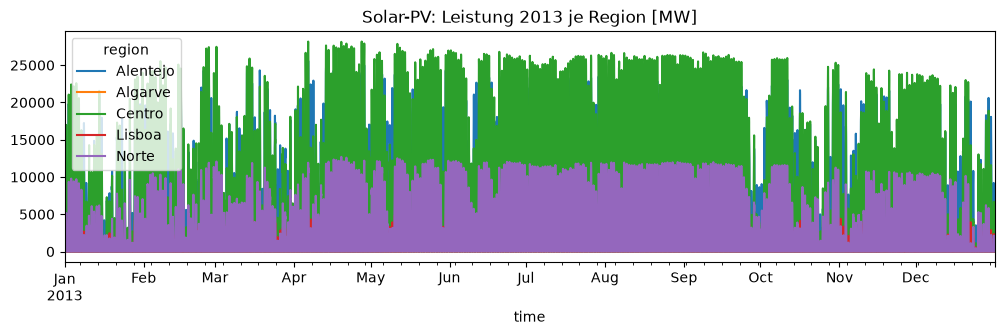

In [39]:
A_solar = cutout.availabilitymatrix(regions_4326, excluder_solar)

capacity_matrix_solar = A_solar.stack(spatial=["y", "x"]) * area * cap_per_sqkm

capacity_factors_solar = cutout.pv(
    panel="CdTe",
    orientation="latitude_optimal",
    matrix=capacity_matrix_solar,
    index=regions_4326.index,
)
capacity_factors_solar.to_pandas().plot(figsize=(12, 3), title="Solar-PV: Leistung 2013 je Region [MW]")

In [40]:
# Sanity-Check: mittags im Sommer muss die Leistung klar > 0 sein
print(capacity_factors_solar.sel(time="2013-07-15T13:00:00"))

<xarray.DataArray 'specific generation' (region: 5)> Size: 40B
array([22916.23104035,  4338.05588812, 23632.33721587,  4588.56696884,
       11094.60960068])
Coordinates:
  * region   (region) object 40B 'Alentejo' 'Algarve' 'Centro' 'Lisboa' 'Norte'
    time     datetime64[ns] 8B 2013-07-15T13:00:00
Attributes: (12/36)
    stored_direction:                         decreasing
    time shift:                               -1 days +23:30:00
    module:                                   era5
    feature:                                  influx
    GRIB_paramId:                             228021
    GRIB_dataType:                            fc
    ...                                       ...
    GRIB_totalNumber:                         0
    GRIB_units:                               J m**-2
    GRIB_surface:                             0.0
    units:                                    MW
    long_name:                                2 metre temperature
    standard_name:                

### 4.2 Onshore-Wind

/Users/luisboettcher/miniforge3/envs/energy/lib/python3.11/site-packages/atlite/convert.py:739: FutureWarning: aggregate_time='legacy' is deprecated and will be removed in a future release. Pass 'sum', 'mean', or None explicitly.
  return cutout.convert_and_aggregate(
INFO:atlite.convert:Convert and aggregate 'wind'.


<Axes: title={'center': 'Onshore-Wind: Leistung 2013 je Region [MW]'}, xlabel='time'>

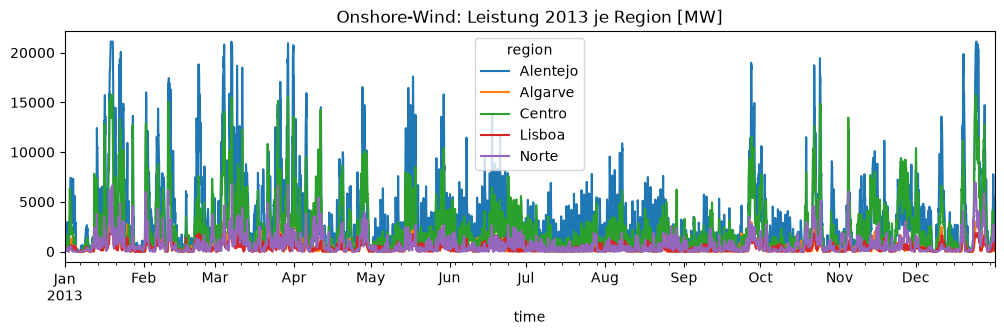

In [41]:
A_wind = cutout.availabilitymatrix(regions_4326, excluder_wind)

capacity_matrix_wind = A_wind.stack(spatial=["y", "x"]) * area * cap_per_sqkm

capacity_factors_onshore = cutout.wind(
    turbine="Vestas_V112_3MW",
    matrix=capacity_matrix_wind,
    index=regions_4326.index,
)
capacity_factors_onshore.to_pandas().plot(figsize=(12, 3), title="Onshore-Wind: Leistung 2013 je Region [MW]")

### 4.3 Offshore-Wind

/Users/luisboettcher/miniforge3/envs/energy/lib/python3.11/site-packages/atlite/convert.py:739: FutureWarning: aggregate_time='legacy' is deprecated and will be removed in a future release. Pass 'sum', 'mean', or None explicitly.
  return cutout.convert_and_aggregate(
INFO:atlite.convert:Convert and aggregate 'wind'.


<Axes: title={'center': 'Offshore-Wind: Leistung 2013 je Region [MW]'}, xlabel='time'>

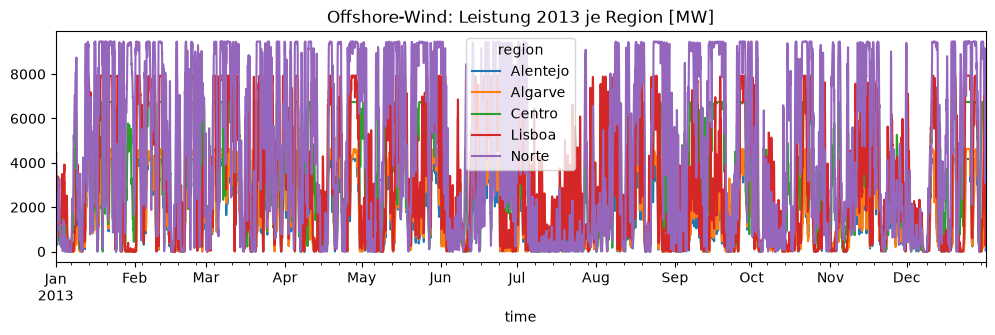

In [42]:
offshore_4326 = offshore_regions.to_crs(4326)

A_offshore = cutout.availabilitymatrix(offshore_4326, excluder_offshore)

capacity_matrix_offshore = A_offshore.stack(spatial=["y", "x"]) * area * cap_per_sqkm

capacity_factors_offshore = cutout.wind(
    turbine="NREL_ReferenceTurbine_5MW_offshore",
    matrix=capacity_matrix_offshore,
    index=offshore_4326.index,
)
capacity_factors_offshore.to_pandas().plot(figsize=(12, 3), title="Offshore-Wind: Leistung 2013 je Region [MW]")

## Zusammenfassung

Dieses Notebook liefert:
- `regions`, `offshore_regions` — 5 Regionen + Offshore-Zuordnung (Geometrien, CRS 3035)
- `capacity_factors_solar`, `capacity_factors_onshore`, `capacity_factors_offshore` —
  stündliche Leistungs-Zeitreihen [MW] für 2013, je Region

Diese Objekte sind der direkte Input für `02_modell.ipynb` (PyPSA-Netzwerk, `p_max_pu`
je Generator/Region nach Normierung auf die installierte Kapazität).

In [44]:
# p_nom_max je Region: Summe der Kapazitätsmatrix über alle Wetterzellen (MW, wetterunabhängig)
p_nom_max_solar = capacity_matrix_solar.sum("spatial")
p_nom_max_onshore = capacity_matrix_wind.sum("spatial")
p_nom_max_offshore = capacity_matrix_offshore.sum("spatial")

print("Installierbare Höchstleistung je Region [MW]:")
print("Solar:   ", p_nom_max_solar.to_pandas().round(0).to_dict())
print("Onshore: ", p_nom_max_onshore.to_pandas().round(0).to_dict())
print("Offshore:", p_nom_max_offshore.to_pandas().round(0).to_dict())

# p_max_pu = Zeitreihe / installierbare Höchstleistung (dimensionslos, 0-1)
p_max_pu_solar = (capacity_factors_solar / p_nom_max_solar).clip(0, 1)
p_max_pu_onshore = (capacity_factors_onshore / p_nom_max_onshore).clip(0, 1)
p_max_pu_offshore = (capacity_factors_offshore / p_nom_max_offshore).clip(0, 1)

# Export für 02_modell.ipynb (Zeitreihen als CSV, p_nom_max als CSV)
p_max_pu_solar.to_pandas().to_csv("p_max_pu_solar.csv")
p_max_pu_onshore.to_pandas().to_csv("p_max_pu_onshore.csv")
p_max_pu_offshore.to_pandas().to_csv("p_max_pu_offshore.csv")

p_nom_max = pd.concat(
    [
        p_nom_max_solar.to_pandas().rename("solar"),
        p_nom_max_onshore.to_pandas().rename("onwind"),
        p_nom_max_offshore.to_pandas().rename("offwind-float"),
    ],
    axis=1,
)
p_nom_max.to_csv("p_nom_max.csv")

print("\nGespeichert: p_max_pu_solar.csv, p_max_pu_onshore.csv, p_max_pu_offshore.csv, p_nom_max.csv")

Installierbare Höchstleistung je Region [MW]:
Solar:    {'Alentejo': 28490.0, 'Algarve': 5383.0, 'Centro': 32138.0, 'Lisboa': 5814.0, 'Norte': 14366.0}
Onshore:  {'Alentejo': 21115.0, 'Algarve': 2965.0, 'Centro': 15779.0, 'Lisboa': 1838.0, 'Norte': 6938.0}
Offshore: {'Alentejo': 4174.0, 'Algarve': 4623.0, 'Centro': 6742.0, 'Lisboa': 7929.0, 'Norte': 9466.0}

Gespeichert: p_max_pu_solar.csv, p_max_pu_onshore.csv, p_max_pu_offshore.csv, p_nom_max.csv
